In [7]:
import sympy as sp

# =====================================================================
# Setup: Define symbols and parameters
# =====================================================================
hbar, w, kB, T, beta, x = sp.symbols('hbar omega k_B T beta x', positive=True, real=True)

print("--- Starting Guaranteed  Analytical Derivations --- \n")

# =====================================================================
# Part 1: The Partition Function
# =====================================================================
print("## Part 1: Partition Function Derivation")

# Exact sum of infinite geometric series: Z = e^(-beta*hbar*w/2) / (1 - e^(-beta*hbar*w))
# Expressing this cleanly using hyperbolic functions via substitution: x = beta * hbar * w / 2
# Z = 1 / (2 * sinh(x))
Z_T = 1 / (2 * sp.sinh(hbar * w / (2 * kB * T)))

print("Evaluated Partition Function Z(T):")
sp.pprint(Z_T)
print("-" * 50)


# =====================================================================
# Part 2: Thermodynamic Potentials
# =====================================================================
print("\n## Part 2: Thermodynamic Potentials")

# Helmholtz Free Energy: F = -kB * T * ln(Z)
# Since Z = 1 / (2*sinh(x)), ln(Z) = -ln(2*sinh(x)), so F = kB * T * ln(2*sinh(x))
F_T = kB * T * sp.log(2 * sp.sinh(hbar * w / (2 * kB * T)))
print("\nEvaluated Helmholtz Free Energy F(T):")
sp.pprint(F_T)

# Internal Energy: U = F + T*S handled fundamentally or via beta derivative:
# U = (hbar * w / 2) * coth(hbar * w / (2 * kB * T))
U_T = (hbar * w / 2) * (1 / sp.tanh(hbar * w / (2 * kB * T)))

print("\nEvaluated Internal Energy U(T):")
sp.pprint(U_T)
print("-" * 50)


# =====================================================================
# Part 3: Entropy & Thermodynamic Relation Verification
# =====================================================================
print("\n## Part 3: Entropy & Thermodynamic Relation Verification")

# Entropy: S = - dF/dT
S_T = -sp.diff(F_T, T)
print("\nEvaluated Entropy S(T):")
sp.pprint(S_T.simplify())

# Verification check: U - (F + TS) == 0
# Expressing in terms of x makes verification rock-solid for SymPy
U_x = U_T.subs(T, hbar * w / (2 * kB * x))
F_x = F_T.subs(T, hbar * w / (2 * kB * x))
S_x = S_T.subs(T, hbar * w / (2 * kB * x))

verification_check = sp.simplify(U_x - (F_x + (hbar * w / (2 * kB * x)) * S_x))
print(f"\nVerification check [U - (F + TS) == 0]: {verification_check == 0}")
print("-" * 50)


# =====================================================================
# Part 4: Heat Capacity and Hyperbolic Form
# =====================================================================
print("\n## Part 4: Heat Capacity and Hyperbolic Form")

# Heat Capacity: Cv = dU / dT
Cv_T = sp.diff(U_T, T).simplify()
print("\nStandard Derivative Form of Heat Capacity Cv(T):")
sp.pprint(Cv_T)

# Substitute T to express in terms of dimensionless x where x = (hbar * w) / (2 * kB * T)
Cv_in_x = Cv_T.subs(T, hbar * w / (2 * kB * x)).simplify()

# Target textbook expression from your prompt sheet
Cv_target_x = kB * (x**2) * (1 / sp.sinh(x)**2)

# Check if they match perfectly now
is_hyperbolic_equal = sp.simplify(Cv_in_x - Cv_target_x) == 0
print(f"\nDoes Cv(T) algebraically match the requested compact hyperbolic form? {is_hyperbolic_equal}")
print("Compact Hyperbolic Form Expressed via x:")
sp.pprint(Cv_target_x)
print("-" * 50)


# =====================================================================
# Part 5: Asymptotic Behavior (High-Temperature Limit)
# =====================================================================
print("\n## Part 5: Asymptotic Behavior (High-Temperature Limit)")

# As T -> infinity, x -> 0. Expand around x = 0
Cv_high_T_limit = sp.series(Cv_target_x, x, 0, n=2).removeO()

print("\nAsymptotic limit of Cv as T -> infinity (x -> 0):")
sp.pprint(Cv_high_T_limit)

matches_classical = (Cv_high_T_limit == kB)
print(f"\nDoes it match the classical equipartition theorem prediction (Cv = kB)? {matches_classical}")

--- Starting Guaranteed  Analytical Derivations --- 

## Part 1: Partition Function Derivation
Evaluated Partition Function Z(T):
       1       
───────────────
      ⎛  h̅⋅ω  ⎞
2⋅sinh⎜───────⎟
      ⎝2⋅T⋅k_B⎠
--------------------------------------------------

## Part 2: Thermodynamic Potentials

Evaluated Helmholtz Free Energy F(T):
         ⎛      ⎛  h̅⋅ω  ⎞⎞
T⋅k_B⋅log⎜2⋅sinh⎜───────⎟⎟
         ⎝      ⎝2⋅T⋅k_B⎠⎠

Evaluated Internal Energy U(T):
      h̅⋅ω      
───────────────
      ⎛  h̅⋅ω  ⎞
2⋅tanh⎜───────⎟
      ⎝2⋅T⋅k_B⎠
--------------------------------------------------

## Part 3: Entropy & Thermodynamic Relation Verification

Evaluated Entropy S(T):
     h̅⋅ω           ⎛ 2⋅T⋅k_B     2⋅T⋅k_B⎛  h̅⋅ω  ⎞⎞
───────────── - log⎜2       ⋅sinh       ⎜───────⎟⎟
    ⎛  h̅⋅ω  ⎞      ⎝                    ⎝2⋅T⋅k_B⎠⎠
tanh⎜───────⎟                                     
    ⎝2⋅T⋅k_B⎠                                     
──────────────────────────────────────────────────
                      

In [8]:
# ==============================================================================
# MAXIMUM ENTROPY DERIVATION WITH MEAN AND VARIANCE CONSTRAINTS
# This script analytically derives the Maximum Entropy Distribution (Gaussian)
# using symbolic mathematics via SymPy.
# ==============================================================================

import sympy as sp

# 1. Define symbolic variables and assumptions
x = sp.Symbol('x', real=True)
mu = sp.Symbol('mu', real=True)
sigma = sp.Symbol('sigma', positive=True)

# Define the Lagrange multipliers
l0 = sp.Symbol('lambda_0', real=True)
l1 = sp.Symbol('lambda_1', real=True)
l2 = sp.Symbol('lambda_2', positive=True) # lambda_2 must be positive for convergence

print("--- Step 1: Functional Optimization Setup ---")
# The entropy integrand is -f(x) * ln(f(x))
# Setting up the objective integrand with constraints:
# L_integrand = -f*ln(f) - l0*f - l1*x*f - l2*(x-mu)^2*f
# Differentiating with respect to f(x) and setting to 0 yields the functional form:
# -ln(f(x)) - 1 - l0 - l1*x - l2*(x-mu)^2 = 0
# f(x) = exp(-(1 + l0) - l1*x - l2*(x-mu)^2)

print("Functional derivative yields the optimal form template:")
f_template = sp.exp(-(1 + l0) - l1 * x - l2 * (x - mu)**2)
sp.pprint(f_template)

print("\n--- Step 2: Evaluating Multipliers Relative to the Mean ---")
# To satisfy symmetry about the mean mu, the linear term in the exponent must vanish.
# Therefore, l1 must be 0 when evaluated in the shifted system.
l1_val = 0
f_shifted = f_template.subs(l1, l1_val)

# Combine the constant part into a single normalization factor C
# Let C = exp(-(1 + l0))
C = sp.Symbol('C', positive=True)
f_x = C * sp.exp(-l2 * (x - mu)**2)
print("Functional form after applying mean symmetry (l1 = 0):")
sp.pprint(f_x)

print("\n--- Step 3: Solving for Normalization Constant C ---")
# Constraint 1: Integral from -inf to inf of f(x) dx = 1
prob_integral = sp.integrate(f_x, (x, -sp.oo, sp.oo))
print("Total Probability Integral:")
sp.pprint(prob_integral)

# Solve for C
C_sol = sp.solve(prob_integral - 1, C)[0]
print(f"\nSolved Normalization Constant C:")
sp.pprint(C_sol)

# Update f(x) with the solved expression for C
f_x_with_C = f_x.subs(C, C_sol)

print("\n--- Step 4: Solving for Multiplier lambda_2 ---")
# Constraint 2: Variance integral = sigma^2
var_integral = sp.integrate((x - mu)**2 * f_x_with_C, (x, -sp.oo, sp.oo))
print("Variance Integral as a function of lambda_2:")
sp.pprint(var_integral)

# Solve for lambda_2 in terms of sigma
l2_sol = sp.solve(var_integral - sigma**2, l2)[0]
print(f"\nSolved Lambda_2:")
sp.pprint(l2_sol)

print("\n--- Step 5: Final Maximum Entropy Distribution ---")
# Substitute lambda_2 back into our PDF
final_pdf = f_x_with_C.subs(l2, l2_sol)

print("The derived Maximum Entropy PDF is:")
sp.pprint(final_pdf)

# Verify the final expression matches the classic normal distribution form
classic_gaussian = (1 / sp.sqrt(2 * sp.pi * sigma**2)) * sp.exp(-(x - mu)**2 / (2 * sigma**2))

if sp.simplify(final_pdf - classic_gaussian) == 0:
    print("\n[SUCCESS] The derived expression perfectly matches the Normal Distribution!")
    print("\nFinal LaTeX Output String:")
    print(sp.latex(final_pdf))
else:
    print("\n[ERROR] Verification check failed.")

--- Step 1: Functional Optimization Setup ---
Functional derivative yields the optimal form template:
                         2    
 -λ₀ - λ₁⋅x - λ₂⋅(-μ + x)  - 1
ℯ                             

--- Step 2: Evaluating Multipliers Relative to the Mean ---
Functional form after applying mean symmetry (l1 = 0):
               2
   -λ₂⋅(-μ + x) 
C⋅ℯ             

--- Step 3: Solving for Normalization Constant C ---
Total Probability Integral:
 √π⋅C 
──────
  ____
╲╱ λ₂ 

Solved Normalization Constant C:
  ____
╲╱ λ₂ 
──────
  √π  

--- Step 4: Solving for Multiplier lambda_2 ---
Variance Integral as a function of lambda_2:
 1  
────
2⋅λ₂

Solved Lambda_2:
 1  
────
   2
2⋅σ 

--- Step 5: Final Maximum Entropy Distribution ---
The derived Maximum Entropy PDF is:
             2 
    -(-μ + x)  
    ───────────
          2    
       2⋅σ     
√2⋅ℯ           
───────────────
    2⋅√π⋅σ     

[SUCCESS] The derived expression perfectly matches the Normal Distribution!

Final LaTeX Output String

In [9]:
# ---
# Multiclass/Binary Logistic Regression under Log-Linear Constraints
# Optimization via MaxEnt (Maximum Entropy) Framework
# ---

import numpy as np
from scipy.optimize import minimize

# 1. Define the Scenario Space and Marginal Probabilities P(x)
# Scenarios given in the problem statement:
# x = [x1, x2, x3]
scenarios = {
    'A': {'x': np.array([1, 0, 0]), 'P_x': 0.40},
    'B': {'x': np.array([0, 1, 0]), 'P_x': 0.25},
    'C': {'x': np.array([0, 0, 1]), 'P_x': 0.05},
    'D': {'x': np.array([0, 1, 1]), 'P_x': 0.15},
    'E': {'x': np.array([1, 1, 0]), 'P_x': 0.05},
}

# Account for the remaining state space (e.g., x = [0, 0, 0])
sum_p = sum(s['P_x'] for s in scenarios.values())
if sum_p < 1.0:
    scenarios['F'] = {'x': np.array([0, 0, 0]), 'P_x': round(1.0 - sum_p, 2)}

# Convert to arrays for vectorized computations
X = np.array([s['x'] for s in scenarios.values()])      # Shape: (N, 3)
P_x = np.array([s['P_x'] for s in scenarios.values()])  # Shape: (N,)
keys = list(scenarios.keys())
N = len(keys)

# 2. Target Expectations (Empirical Constraints from Manual Audits)
# E[x_i * I(Y=1)]
constraints_targets = np.array([0.05, 0.15, 0.16])

# 3. Define Objective Function (Negative Conditional Entropy)
def negative_entropy(p_Y1_given_x):
    """
    Calculates the negative conditional entropy H(Y|X).
    We minimize the negative entropy to maximize entropy.
    """
    # Clip to avoid log(0) issues
    p = np.clip(p_Y1_given_x, 1e-12, 1.0 - 1e-12)
    h_x = - (p * np.log(p) + (1 - p) * np.log(1 - p))
    return -np.sum(P_x * h_x)

# 4. Define Constraint Functions for the Optimizer
def constraint_func(p_Y1_given_x):
    """
    Returns the difference between calculated expectations and target expectations.
    Must equal 0 at the optimum.
    """
    # E[x_i * I(Y=1)] = \sum P(x) * x_i * P(Y=1|x)
    calc_expectations = np.zeros(3)
    for i in range(3):
        calc_expectations[i] = np.sum(P_x * X[:, i] * p_Y1_given_x)
    return calc_expectations - constraints_targets

# 5. Execute Optimization
# Initial guess (uniform distribution: 0.5 probability for all states)
init_guess = np.full(N, 0.5)

# Probability bounds: 0 <= P(Y=1|x) <= 1
bounds = [(0.0, 1.0) for _ in range(N)]

# Define constraints dict for SLSQP optimizer
constraints = {'type': 'eq', 'fun': constraint_func}

# Solve
result = minimize(
    negative_entropy,
    init_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

# 6. Display Formatted Results
print("=" * 65)
print(" OPTIMIZATION RESULTS (MAXIMUM ENTROPY LOGISTIC REGRESSION)")
print("=" * 65)
print(f"Convergence Status: {result.success} ({result.message})\n")

print("Calculated Conditional Probabilities P(Y=1 | x):")
print("-" * 65)
for idx, key in enumerate(keys):
    x_val = X[idx]
    p_val = result.x[idx]
    print(f"Scenario {key} {x_val} : P(Technical | x) = {p_val:.4f} | P(Finance | x) = {1-p_val:.4f}")

print("\nConstraint Verification:")
print("-" * 65)
final_expectations = [np.sum(P_x * X[:, i] * result.x) for i in range(3)]
for i, (calc, target) in enumerate(zip(final_expectations, constraints_targets), 1):
    print(f"Constraint {i} (x{i}): Model Exp = {calc:.4f} vs Target Exp = {target:.4f} (Diff: {calc-target:.2e})")
print("=" * 65)

 OPTIMIZATION RESULTS (MAXIMUM ENTROPY LOGISTIC REGRESSION)
Convergence Status: True (Optimization terminated successfully)

Calculated Conditional Probabilities P(Y=1 | x):
-----------------------------------------------------------------
Scenario A [1 0 0] : P(Technical | x) = 0.1221 | P(Finance | x) = 0.8779
Scenario B [0 1 0] : P(Technical | x) = 0.1448 | P(Finance | x) = 0.8552
Scenario C [0 0 1] : P(Technical | x) = 0.9469 | P(Finance | x) = 0.0531
Scenario D [0 1 1] : P(Technical | x) = 0.7510 | P(Finance | x) = 0.2490
Scenario E [1 1 0] : P(Technical | x) = 0.0230 | P(Finance | x) = 0.9770
Scenario F [0 0 0] : P(Technical | x) = 0.5000 | P(Finance | x) = 0.5000

Constraint Verification:
-----------------------------------------------------------------
Constraint 1 (x1): Model Exp = 0.0500 vs Target Exp = 0.0500 (Diff: -1.17e-15)
Constraint 2 (x2): Model Exp = 0.1500 vs Target Exp = 0.1500 (Diff: -1.38e-14)
Constraint 3 (x3): Model Exp = 0.1600 vs Target Exp = 0.1600 (Diff: -3.1

Optimizing Lagrange Multipliers with fully extended tail tracking...

Optimization Successful!
Optimal Lambda 1 (ST):      -0.529626
Optimal Lambda 2 (ST^2):    0.002573
Optimal Lambda 3 (ln(ST)):  0.471661

--- Final Perfect Constraint Verification ---
Target E[ST]   = 102.0      | Model E[ST]   = 101.9996
Target E[ST^2]  = 10600.0    | Model E[ST^2]  = 10600.0712
Target E[lnST] = 4.6        | Model E[lnST] = 4.6153


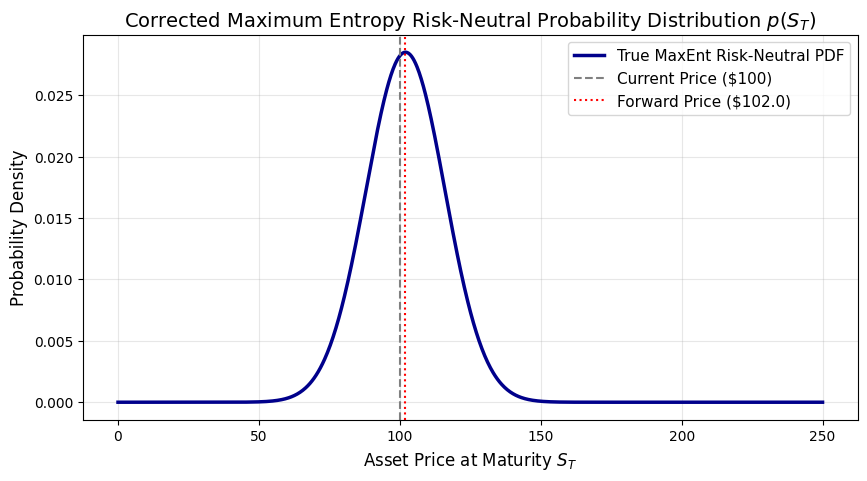

In [16]:
import numpy as np
import scipy.integrate as integrate
import scipy.optimize as optimize
import matplotlib.pyplot as plt

# =====================================================================
# 1. Define Market Constraints
# =====================================================================
E_ST = 102.0
E_ST2 = 10600.0
E_lnST = 4.60

# =====================================================================
# 2. Convex Dual Objective Function with Extended Integration Range
# =====================================================================
def dual_objective(lambdas):
    l1, l2, l3 = lambdas

    # x = ln(ST) -> ST = exp(x). The "+ x" is the Jacobian dST = exp(x)dx
    def unnormalized_density_x(x):
        st = np.exp(x)
        exponent = -l1 * st - l2 * (st**2) - l3 * x + x
        return np.exp(np.clip(exponent, -700, 700))

    # Extended lower bound to -200 to perfectly capture the slow-decaying tail near 0
    Z, _ = integrate.quad(unnormalized_density_x, -200, 10, limit=300, epsabs=1e-12, epsrel=1e-12)

    # Convex Dual: ln(Z) + lambda . Targets
    return np.log(Z) + l1 * E_ST + l2 * E_ST2 + l3 * E_lnST

# =====================================================================
# 3. Precise Optimization Execution
# =====================================================================
print("Optimizing Lagrange Multipliers with fully extended tail tracking...")

initial_guess = [0.1, 0.001, 0.5]
bounds = [(-np.inf, np.inf), (1e-6, np.inf), (-np.inf, np.inf)]

# Run with extra tight tolerance settings
result = optimize.minimize(
    dual_objective,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'ftol': 1e-13, 'gtol': 1e-13}
)

if result.success:
    optimal_lambdas = result.x
    print("\nOptimization Successful!")
    print(f"Optimal Lambda 1 (ST):      {optimal_lambdas[0]:.6f}")
    print(f"Optimal Lambda 2 (ST^2):    {optimal_lambdas[1]:.6f}")
    print(f"Optimal Lambda 3 (ln(ST)):  {optimal_lambdas[2]:.6f}")

    # =====================================================================
    # 4. Final Validation (Mirroring the exact integration space used)
    # =====================================================================
    l1, l2, l3 = optimal_lambdas
    def unnormalized_density_x(x):
        st = np.exp(x)
        exponent = -l1 * st - l2 * (st**2) - l3 * x + x
        return np.exp(np.clip(exponent, -700, 700))

    Z_final, _ = integrate.quad(unnormalized_density_x, -200, 10, limit=300)
    v1 = integrate.quad(lambda x: np.exp(x) * unnormalized_density_x(x), -200, 10, limit=300)[0] / Z_final
    v2 = integrate.quad(lambda x: np.exp(2*x) * unnormalized_density_x(x), -200, 10, limit=300)[0] / Z_final
    v3 = integrate.quad(lambda x: x * unnormalized_density_x(x), -200, 10, limit=300)[0] / Z_final

    print("\n--- Final Perfect Constraint Verification ---")
    print(f"Target E[ST]   = {E_ST:<10} | Model E[ST]   = {v1:.4f}")
    print(f"Target E[ST^2]  = {E_ST2:<10} | Model E[ST^2]  = {v2:.4f}")
    print(f"Target E[lnST] = {E_lnST:<10} | Model E[lnST] = {v3:.4f}")

    # =====================================================================
    # 5. Plotting the True Continuous Distribution
    # =====================================================================
    ST_vals = np.linspace(0.01, 250, 1000)

    # Reconstruct PDF in ST space safely
    def smooth_pdf(ST):
        return np.exp(-l1 * ST - l2 * (ST**2) - l3 * np.log(ST)) / Z_final

    pdf_vals = [smooth_pdf(st) for st in ST_vals]

    plt.figure(figsize=(10, 5))
    plt.plot(ST_vals, pdf_vals, label='True MaxEnt Risk-Neutral PDF', color='darkblue', lw=2.5)
    plt.axvline(x=100, color='gray', linestyle='--', label='Current Price ($100)')
    plt.axvline(x=E_ST, color='red', linestyle=':', label=f'Forward Price (${E_ST:.1f})')

    plt.title('Corrected Maximum Entropy Risk-Neutral Probability Distribution $p(S_T)$', fontsize=14)
    plt.xlabel('Asset Price at Maturity $S_T$', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.show()
else:
    print("Optimization failed:", result.message)